In [1]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import numpy as np
import matplotlib.pyplot as plt

## Load the dataset

In [2]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("kinozyne/5-classes-of-fruits-dataset-train-test")

print("Path to dataset files:", path)

Using Colab cache for faster access to the '5-classes-of-fruits-dataset-train-test' dataset.
Path to dataset files: /kaggle/input/5-classes-of-fruits-dataset-train-test


## Assign the path

In [3]:
import os

TRAIN_DIR = f"{path}/dataset/train"
TEST_DIR = f"{path}/dataset/test"

# Check if directories exist
if not os.path.exists(TRAIN_DIR):
    print(f"Error: Train directory not found at {TRAIN_DIR}")
elif not os.path.exists(TEST_DIR):
    print(f"Error: Test directory not found at {TEST_DIR}")
else:
    print(f"Train directory: {TRAIN_DIR}")
    print(f"Test directory: {TEST_DIR}")

Train directory: /kaggle/input/5-classes-of-fruits-dataset-train-test/dataset/train
Test directory: /kaggle/input/5-classes-of-fruits-dataset-train-test/dataset/test


## Data Augmentation

In [4]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Data augmentation and normalization
train_datagen = ImageDataGenerator(
    rescale=1./255,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True)

test_datagen = ImageDataGenerator(rescale=1./255)

# Prepare data generators
train_generator = train_datagen.flow_from_directory(
    TRAIN_DIR,
    target_size=(192, 192),
    batch_size=32,
    class_mode='categorical')

test_generator = test_datagen.flow_from_directory(
    TEST_DIR,
    target_size=(192, 192),
    batch_size=32,
    class_mode='categorical')

print("Data generators prepared.")

Found 150 images belonging to 5 classes.
Found 50 images belonging to 5 classes.
Data generators prepared.


## CNN Model

In [5]:
from tensorflow.keras import Input, Model

# Define the input layer
input_tensor = Input(shape=(192, 192, 3))

# Build the model using the functional API to avoid the input_shape warning
x = layers.Conv2D(32, (3, 3), activation='relu')(input_tensor)
x = layers.Conv2D(32, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.Conv2D(64, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.Conv2D(128, (3, 3), activation='relu')(x)
x = layers.MaxPooling2D((2, 2))(x)
x = layers.Flatten()(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.5)(x)
output_tensor = layers.Dense(train_generator.num_classes, activation='softmax')(x) # Use num_classes from the generator

model = Model(inputs=input_tensor, outputs=output_tensor)

# Compile the model
model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=0.0001),
              loss='categorical_crossentropy', # Use categorical_crossentropy for one-hot encoded labels
              metrics=['accuracy'])

model.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 192, 192, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 190, 190, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 188, 188, 32)   │         9,248 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 94, 94, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 92, 92, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 90, 90, 64)     │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 45, 45, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 43, 43, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 41, 41, 128)    │       147,584 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 51200)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     6,553,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 6,841,381 (26.10 MB)

 Trainable params: 6,841,381 (26.10 MB)

 Non-trainable params: 0 (0.00 B)

## Start Training

In [6]:
from tensorflow.keras.callbacks import EarlyStopping, LearningRateScheduler
import math

# Define the Early Stopping callback
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)

# Define a learning rate function
def exponential_decay(epoch, learning_rate):
    initial_lrate = 0.001
    k = 0.1
    lrate = initial_lrate * math.exp(-k*epoch)
    return lrate

# Create the learning rate scheduler callback
lr_scheduler = LearningRateScheduler(exponential_decay)

# Train the model with the callback
history = model.fit(
    train_generator,
    steps_per_epoch=train_generator.samples // train_generator.batch_size,
    epochs=60,
    callbacks=[early_stopping, lr_scheduler] # Add the callbacks here
)

/usr/local/lib/python3.12/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 28s 5s/step - accuracy: 0.2034 - loss: 1.8586 - learning_rate: 0.0010
Epoch 2/60


/usr/local/lib/python3.12/dist-packages/keras/src/callbacks/early_stopping.py:153: UserWarning: Early stopping conditioned on metric `val_loss` which is not available. Available metrics are: accuracy,loss
  current = self.get_monitor_value(logs)


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.2812 - loss: 1.6006 - learning_rate: 9.0484e-04
Epoch 3/60


/usr/local/lib/python3.12/dist-packages/keras/src/trainers/epoch_iterator.py:116: UserWarning: Your input ran out of data; interrupting training. Make sure that your dataset or generator can generate at least `steps_per_epoch * epochs` batches. You may need to use the `.repeat()` function when building your dataset.
  self._interrupted_warning()


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.3199 - loss: 1.5645 - learning_rate: 8.1873e-04
Epoch 4/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.2188 - loss: 1.5539 - learning_rate: 7.4082e-04
Epoch 5/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4030 - loss: 1.3521 - learning_rate: 6.7032e-04
Epoch 6/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4688 - loss: 1.2628 - learning_rate: 6.0653e-04
Epoch 7/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 9s 1s/step - accuracy: 0.4069 - loss: 1.2122 - learning_rate: 5.4881e-04
Epoch 8/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.3438 - loss: 1.2556 - learning_rate: 4.9659e-04
Epoch 9/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.5245 - loss: 1.1685 - learning_rate: 4.4933e-04
Epoch 10/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.4375 - loss: 1.0070 - learning_rate: 4.0657e-04
Epoch 11/60
4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 1s/step - accuracy: 0.4636 - loss: 1.1149 - learning_rate: 3.6788e-04
Epoch 12/60
4/4 ━━━━━━━━

## Evalutate and Save Model

In [7]:
model.evaluate(test_generator)

2/2 ━━━━━━━━━━━━━━━━━━━━ 6s 2s/step - accuracy: 0.6112 - loss: 0.7705


[0.7613515257835388, 0.6200000047683716]

In [10]:
model.save("my_cnn_model.keras")
print("Model saved successfully!")

Model saved successfully!


## Prediction

Predicting on image: /root/.cache/kagglehub/datasets/kinozyne/5-classes-of-fruits-dataset-train-test/versions/1/dataset/test/banana fruit/Image_39.jpg


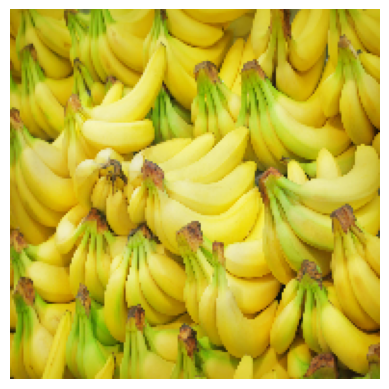

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 484ms/step

Prediction probabilities:
apple fruit: 0.0193 (1.93%)
banana fruit: 0.8080 (80.80%)
cherry fruit: 0.0634 (6.34%)
orange fruit: 0.1043 (10.43%)
strawberry fruiit: 0.0050 (0.50%)

Predicted class: banana fruit
------------------------------


In [17]:
from tensorflow.keras.models import load_model
from tensorflow.keras.preprocessing import image
import numpy as np # Make sure numpy is imported
import matplotlib.pyplot as plt # Import matplotlib

# Load the saved model
loaded_model = load_model("my_cnn_model.keras") # Load the model saved in this notebook

image_paths_to_predict = ['/root/.cache/kagglehub/datasets/kinozyne/5-classes-of-fruits-dataset-train-test/versions/1/dataset/test/banana fruit/Image_39.jpg'] # Corrected filename capitalization

for image_path_to_predict in image_paths_to_predict:
    print(f"Predicting on image: {image_path_to_predict}")

    # Load and preprocess the image
    img = image.load_img(image_path_to_predict, target_size=(192, 192))
    img_array = image.img_to_array(img)
    img_array = np.expand_dims(img_array, axis=0)
    img_array /= 255.0  # Rescale the image

    # Display the image
    plt.imshow(img)
    plt.axis('off') # Hide axes
    plt.show()

    # Make a prediction
    predictions = loaded_model.predict(img_array)

    # Get the class labels from the test generator
    class_labels = list(test_generator.class_indices.keys())

    # Display the results
    print("\nPrediction probabilities:")
    for i, probability in enumerate(predictions[0]):
        print(f"{class_labels[i]}: {probability:.4f} ({probability*100:.2f}%)")

    predicted_class_index = np.argmax(predictions)
    predicted_class_label = class_labels[predicted_class_index]
    print(f"\nPredicted class: {predicted_class_label}")
    print("-" * 30)